# Advanced Phantom Generation

Five contour styles for non-overlapping inclusions:
- **smooth** : ellipse / circle (smooth arc boundary)
- **wavy** : sinusoidal radial perturbation (organic contour)
- **angular** : low-vertex polygon with spikiness (sharp corners)
- **star** : alternating inner/outer radii (concave edges)
- **perlin** : Fourier-harmonic modulated radius (natural blob)

Additional: elastic deformation, Perlin noise thresholding, Perlin background perturbation.

In [2]:
import sys, os, importlib

# Ensure project root is on sys.path regardless of kernel cwd
_project_root = os.path.normpath(os.path.join(os.path.dirname(os.path.abspath("__file__")), '..'))
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)
os.chdir(_project_root)

import numpy as np
import matplotlib.pyplot as plt

import src.data.advanced_phantom as _ap
importlib.reload(_ap)
from src.data.advanced_phantom import (
    create_phantoms_advanced, create_perlin_phantom,
    create_phantoms_v2, elastic_deform,
    create_conductivity_map, _draw_shape,
    CONTOUR_STYLES, _DOMAIN_MASK, _DOMAIN_CENTER
)

import src.data.phantom_generator as _pg
importlib.reload(_pg)
from src.data.phantom_generator import create_phantoms as create_phantoms_legacy

rng = np.random.default_rng(42)
print(f"Project root: {_project_root}")
print(f"Contour styles: {CONTOUR_STYLES}")

Project root: d:\010_CodePrograms\E
Contour styles: ['smooth', 'wavy', 'angular', 'star', 'perlin']


## 1. Five Contour Styles

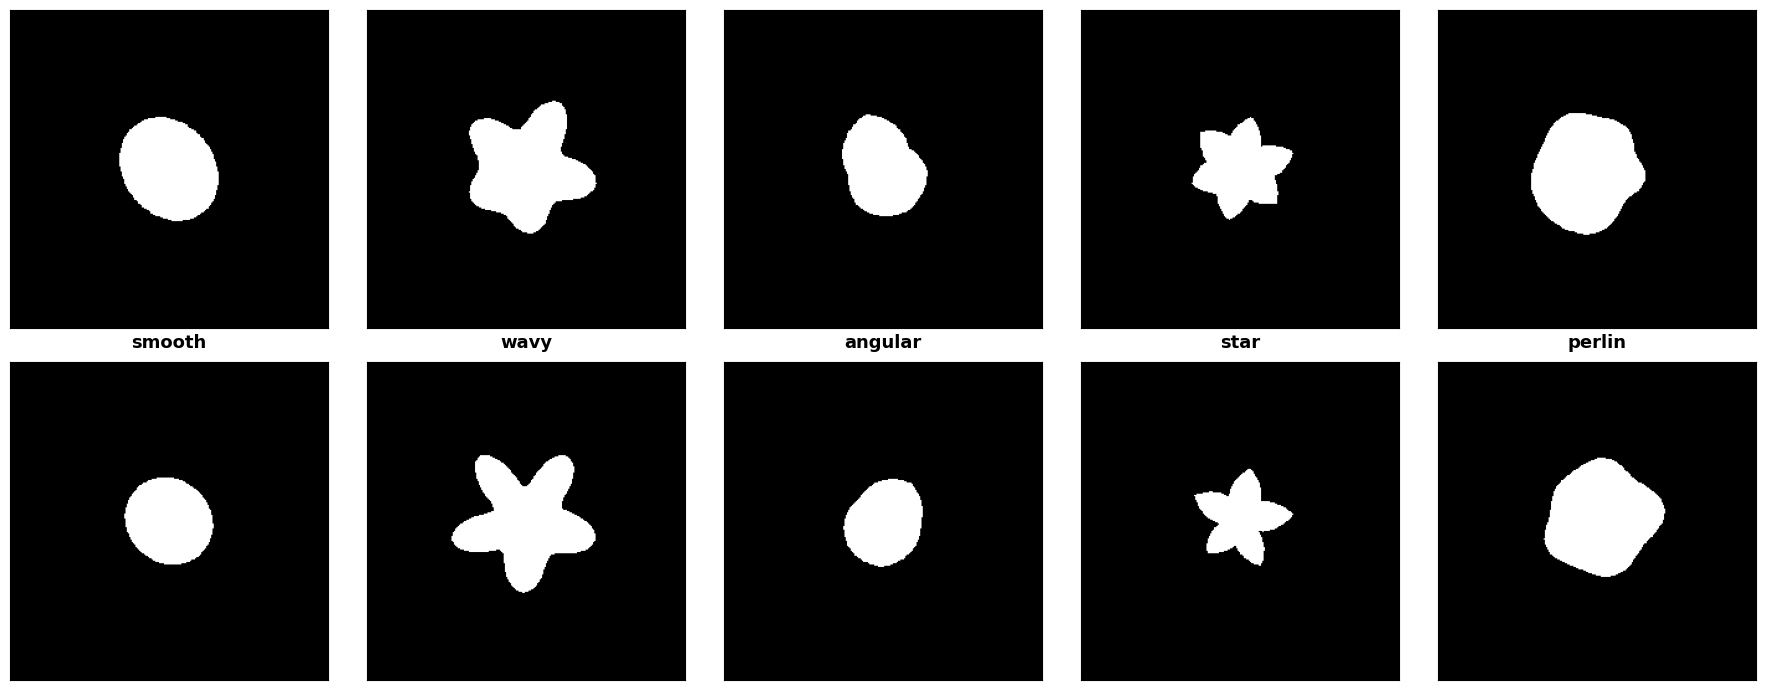

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for row in range(2):
    for col, style in enumerate(CONTOUR_STYLES):
        seed = row * 5 + col + 1
        img = _draw_shape(_DOMAIN_CENTER, _DOMAIN_CENTER, 45,
                          style, fill_val=2,
                          rng=np.random.default_rng(seed))
        img[~_DOMAIN_MASK] = 0
        axes[row, col].imshow(img.T, cmap='gray', origin='lower', vmin=0, vmax=2)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
        if row == 0:
            axes[row, col].set_xlabel(style, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Non-overlapping Multi-inclusion Phantoms

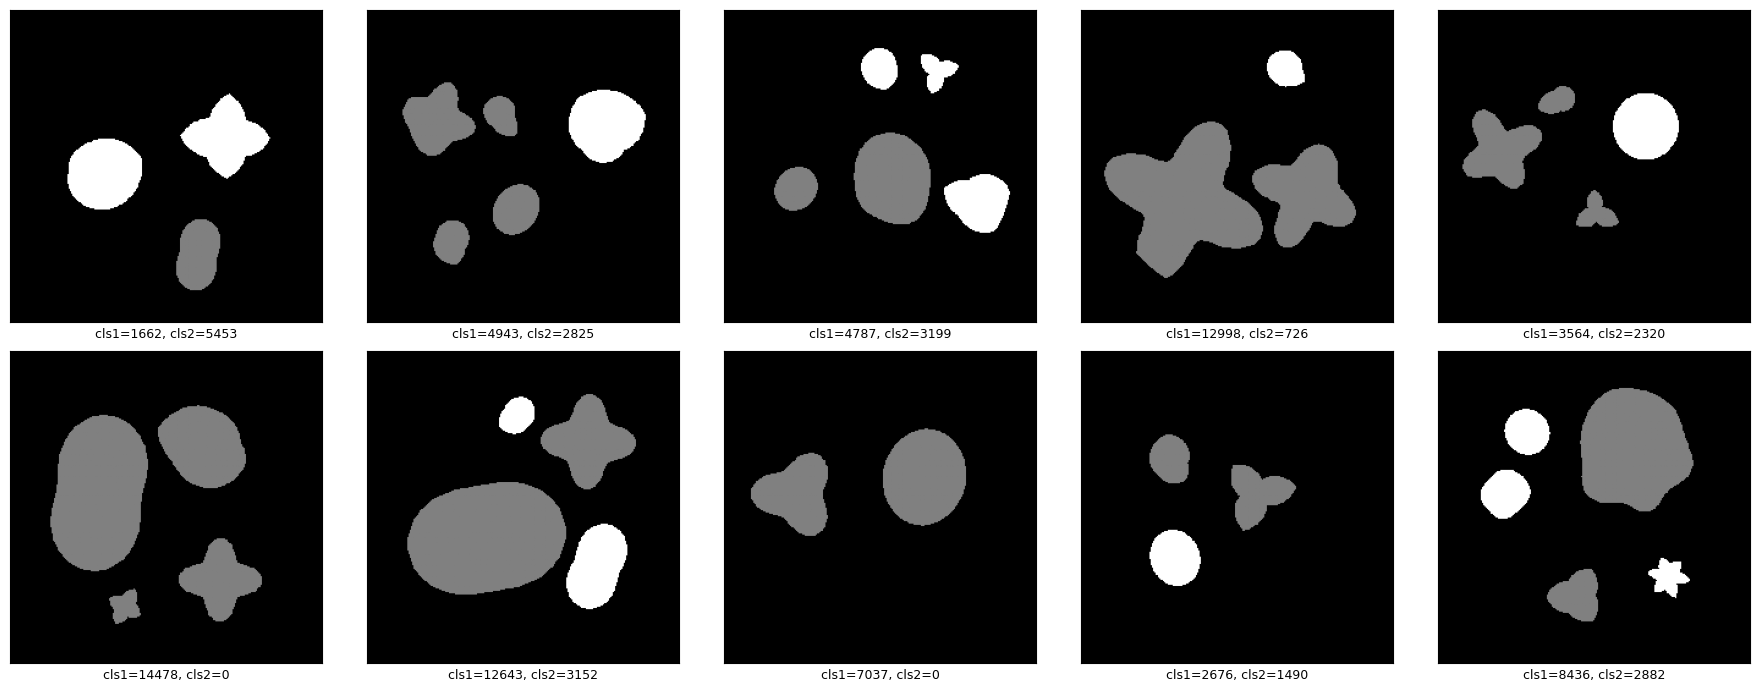

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for i in range(10):
    r, c = divmod(i, 5)
    mask = create_phantoms_advanced(rng=np.random.default_rng(i * 13 + 7))
    axes[r, c].imshow(mask.T, cmap='gray', origin='lower', vmin=0, vmax=2)
    axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
    n1, n2 = (mask==1).sum(), (mask==2).sum()
    n_obj = len(np.unique(mask)) - 1  # exclude background
    axes[r, c].set_xlabel(f'cls1={n1}, cls2={n2}', fontsize=9)

plt.tight_layout()
plt.show()

## 3. Elastic Deformation Effect

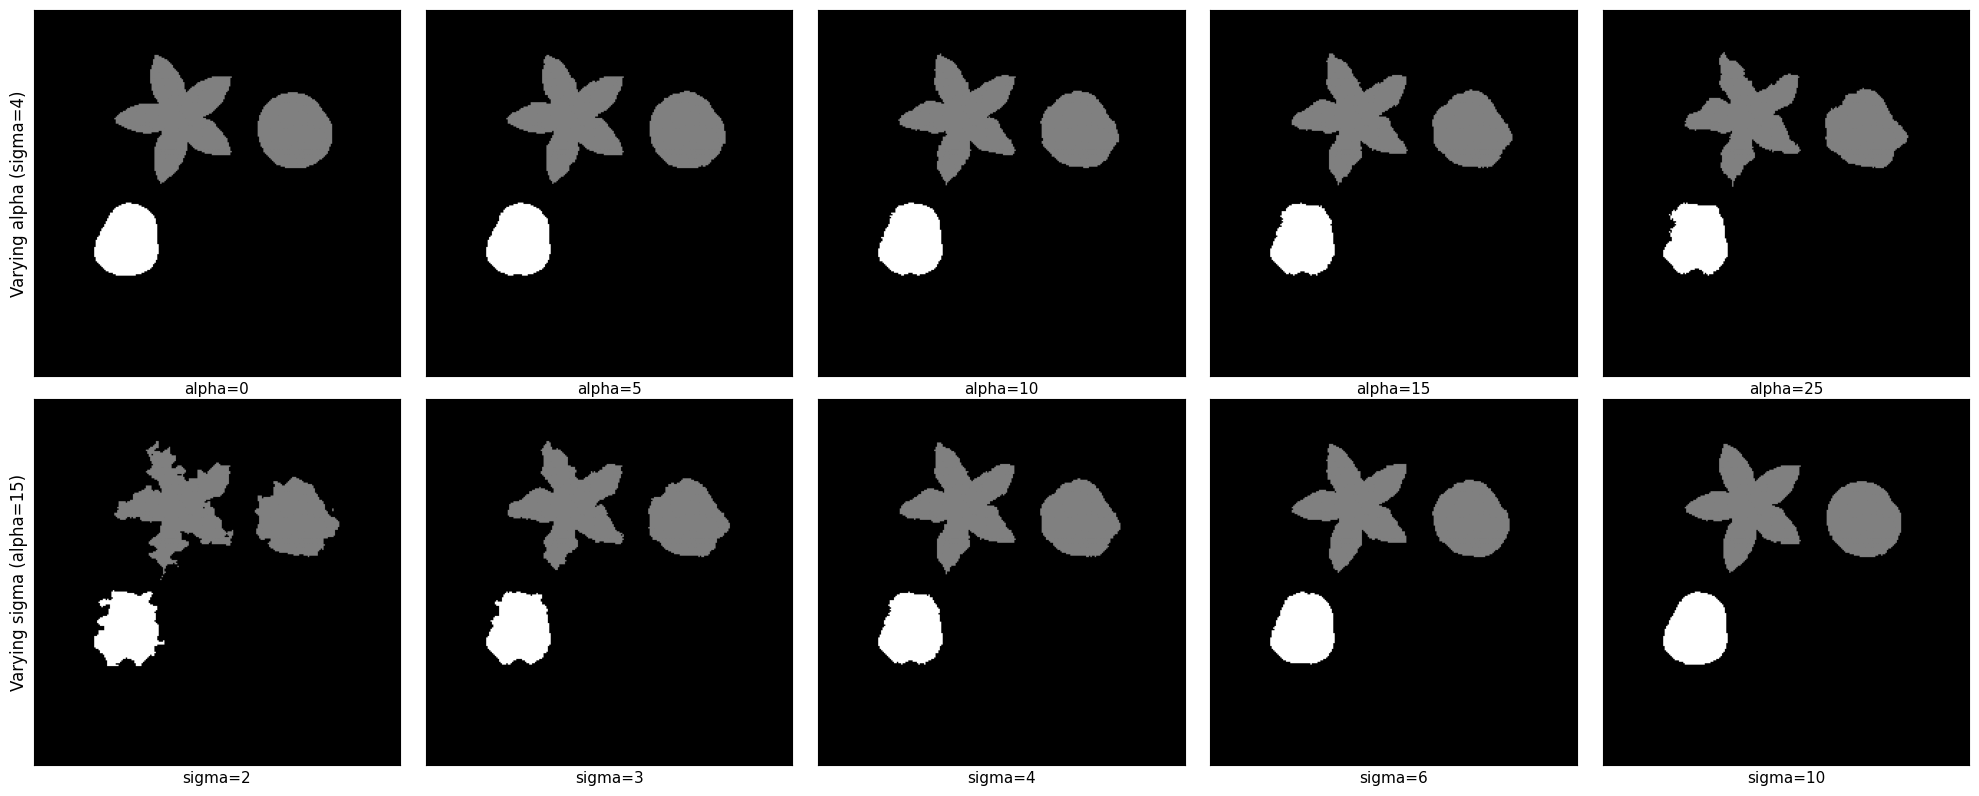

In [5]:
base = create_phantoms_advanced(n_inclusions=3, rng=np.random.default_rng(10))

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

# Row 1: Varying alpha
alphas = [0, 5, 10, 15, 25]
for i, alpha in enumerate(alphas):
    if alpha == 0:
        deformed = base.copy()
    else:
        deformed = elastic_deform(base, alpha=alpha, sigma=4.0,
                                  rng=np.random.default_rng(99))
    deformed[~_DOMAIN_MASK] = 0
    axes[0, i].imshow(deformed.T, cmap='gray', origin='lower', vmin=0, vmax=2)
    axes[0, i].set_xticks([]); axes[0, i].set_yticks([])
    axes[0, i].set_xlabel(f'alpha={alpha}', fontsize=11)
axes[0, 0].set_ylabel('Varying alpha (sigma=4)', fontsize=12)

# Row 2: Varying sigma
sigmas = [2, 3, 4, 6, 10]
for i, sigma in enumerate(sigmas):
    deformed = elastic_deform(base, alpha=15.0, sigma=sigma,
                              rng=np.random.default_rng(99))
    deformed[~_DOMAIN_MASK] = 0
    axes[1, i].imshow(deformed.T, cmap='gray', origin='lower', vmin=0, vmax=2)
    axes[1, i].set_xticks([]); axes[1, i].set_yticks([])
    axes[1, i].set_xlabel(f'sigma={sigma}', fontsize=11)
axes[1, 0].set_ylabel('Varying sigma (alpha=15)', fontsize=12)

plt.tight_layout()
plt.show()

## 4. Legacy vs Contour vs Perlin vs Mixed (v2)

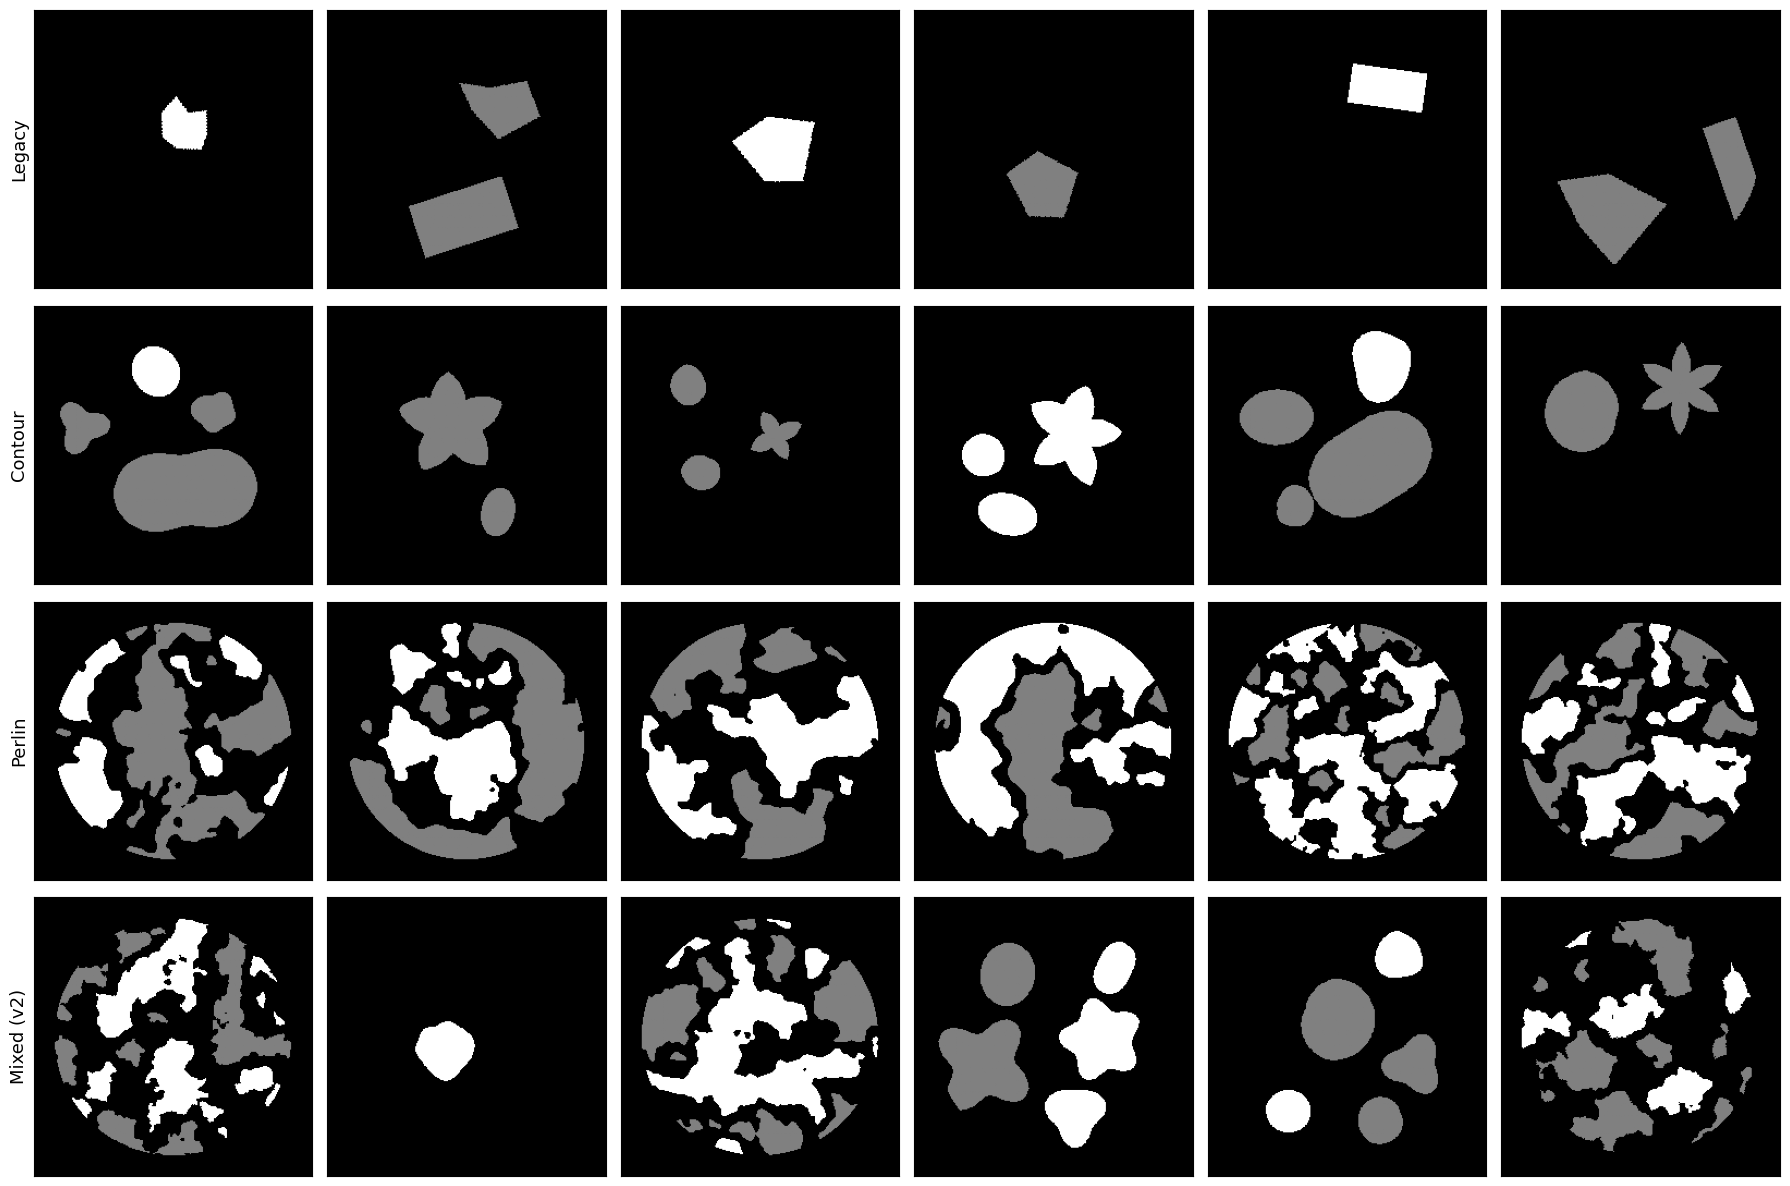

In [6]:
fig, axes = plt.subplots(4, 6, figsize=(18, 12))
row_labels = ['Legacy', 'Contour', 'Perlin', 'Mixed (v2)']

# Row 1: Legacy
np.random.seed(0)
for i in range(6):
    mask = create_phantoms_legacy()
    axes[0, i].imshow(mask.T, cmap='gray', origin='lower', vmin=0, vmax=2)
    axes[0, i].set_xticks([]); axes[0, i].set_yticks([])

# Row 2: Contour-based
for i in range(6):
    mask = create_phantoms_advanced(rng=np.random.default_rng(100+i))
    axes[1, i].imshow(mask.T, cmap='gray', origin='lower', vmin=0, vmax=2)
    axes[1, i].set_xticks([]); axes[1, i].set_yticks([])

# Row 3: Perlin threshold
for i in range(6):
    mask = create_perlin_phantom(rng=np.random.default_rng(200+i))
    axes[2, i].imshow(mask.T, cmap='gray', origin='lower', vmin=0, vmax=2)
    axes[2, i].set_xticks([]); axes[2, i].set_yticks([])

# Row 4: Mixed v2
for i in range(6):
    mask = create_phantoms_v2(rng=np.random.default_rng(300+i))
    axes[3, i].imshow(mask.T, cmap='gray', origin='lower', vmin=0, vmax=2)
    axes[3, i].set_xticks([]); axes[3, i].set_yticks([])

for r, label in enumerate(row_labels):
    axes[r, 0].set_ylabel(label, fontsize=13)

plt.tight_layout()
plt.show()

## 5. Conductivity Map (with Perlin Background)

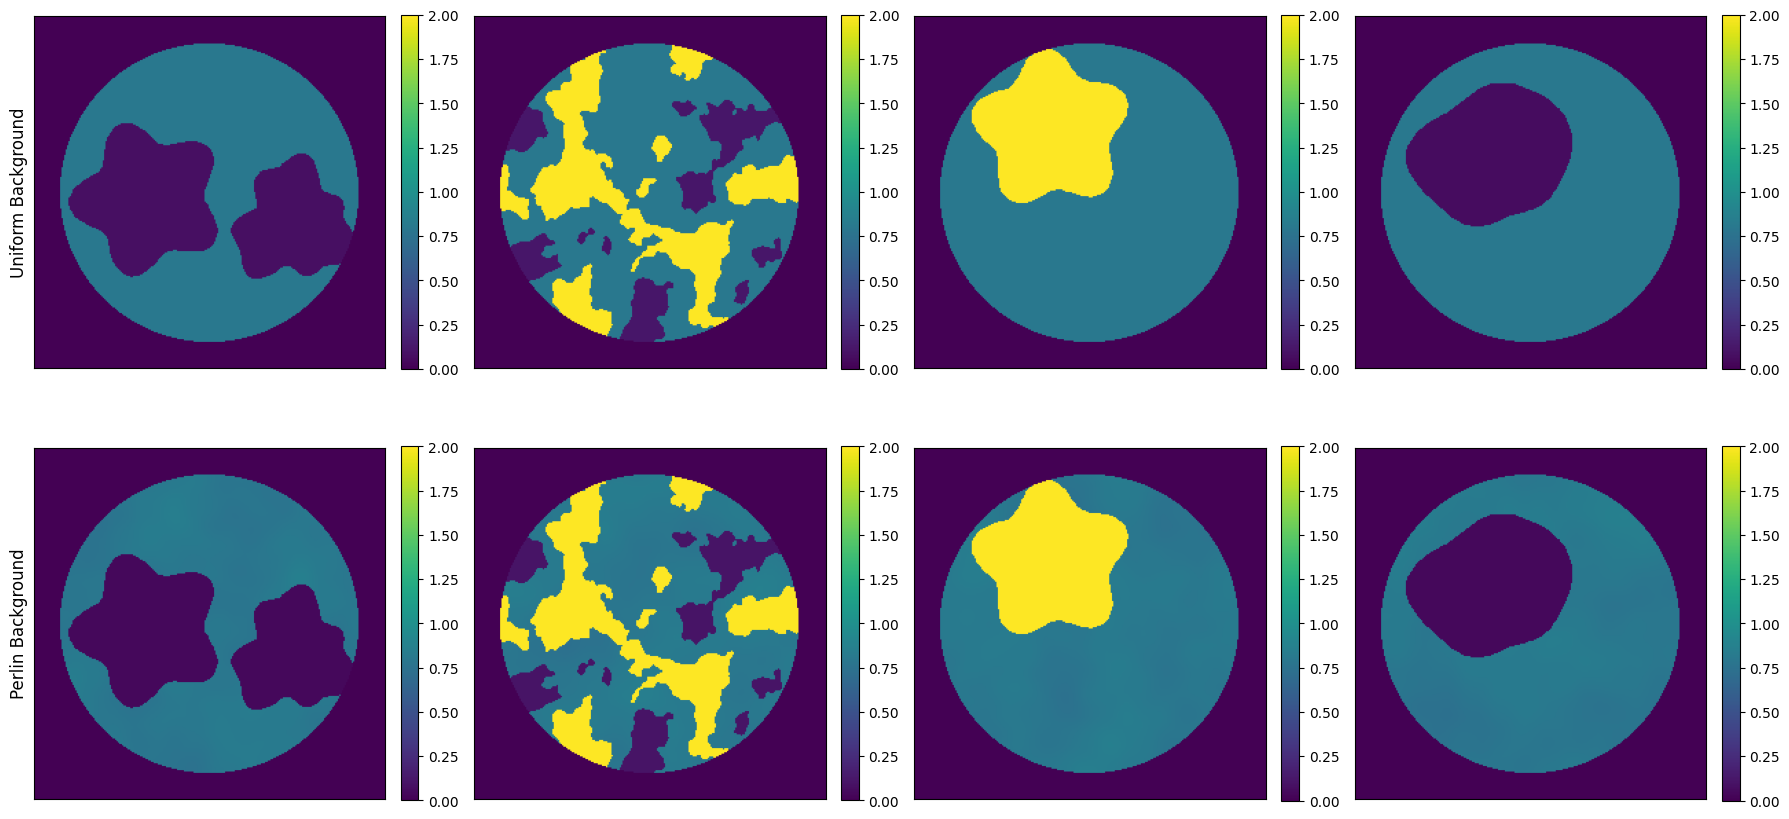

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i in range(4):
    mask = create_phantoms_v2(rng=np.random.default_rng(400 + i))
    
    sigma_no_bg = create_conductivity_map(mask, perlin_bg=False,
                                          rng=np.random.default_rng(500+i))
    sigma_with_bg = create_conductivity_map(mask, perlin_bg=True,
                                            perlin_bg_amp=0.08,
                                            rng=np.random.default_rng(600+i))
    
    im0 = axes[0, i].imshow(sigma_no_bg.T, cmap='viridis', origin='lower',
                             vmin=0, vmax=2)
    axes[0, i].set_xticks([]); axes[0, i].set_yticks([])
    plt.colorbar(im0, ax=axes[0, i], fraction=0.046, pad=0.04)
    
    im1 = axes[1, i].imshow(sigma_with_bg.T, cmap='viridis', origin='lower',
                             vmin=0, vmax=2)
    axes[1, i].set_xticks([]); axes[1, i].set_yticks([])
    plt.colorbar(im1, ax=axes[1, i], fraction=0.046, pad=0.04)

axes[0, 0].set_ylabel('Uniform Background', fontsize=12)
axes[1, 0].set_ylabel('Perlin Background', fontsize=12)

plt.tight_layout()
plt.show()

## 6. Speed Test

In [8]:
import time

methods = ['contour', 'perlin', 'legacy', 'mixed']
n_test = 100

for method in methods:
    rng_test = np.random.default_rng(0)
    if method == 'legacy':
        np.random.seed(0)
    t0 = time.perf_counter()
    for _ in range(n_test):
        if method == 'legacy':
            create_phantoms_legacy()
        else:
            m = method if method != 'mixed' else None
            create_phantoms_v2(method=m, rng=rng_test)
    elapsed = time.perf_counter() - t0
    print(f'{method:10s}: {elapsed:.3f}s for {n_test} samples '
          f'({elapsed/n_test*1000:.1f} ms/sample)')

contour   : 0.270s for 100 samples (2.7 ms/sample)
perlin    : 4.307s for 100 samples (43.1 ms/sample)
legacy    : 0.176s for 100 samples (1.8 ms/sample)
mixed     : 1.236s for 100 samples (12.4 ms/sample)


## 7. Per-style Gallery (fixed style, multiple seeds)

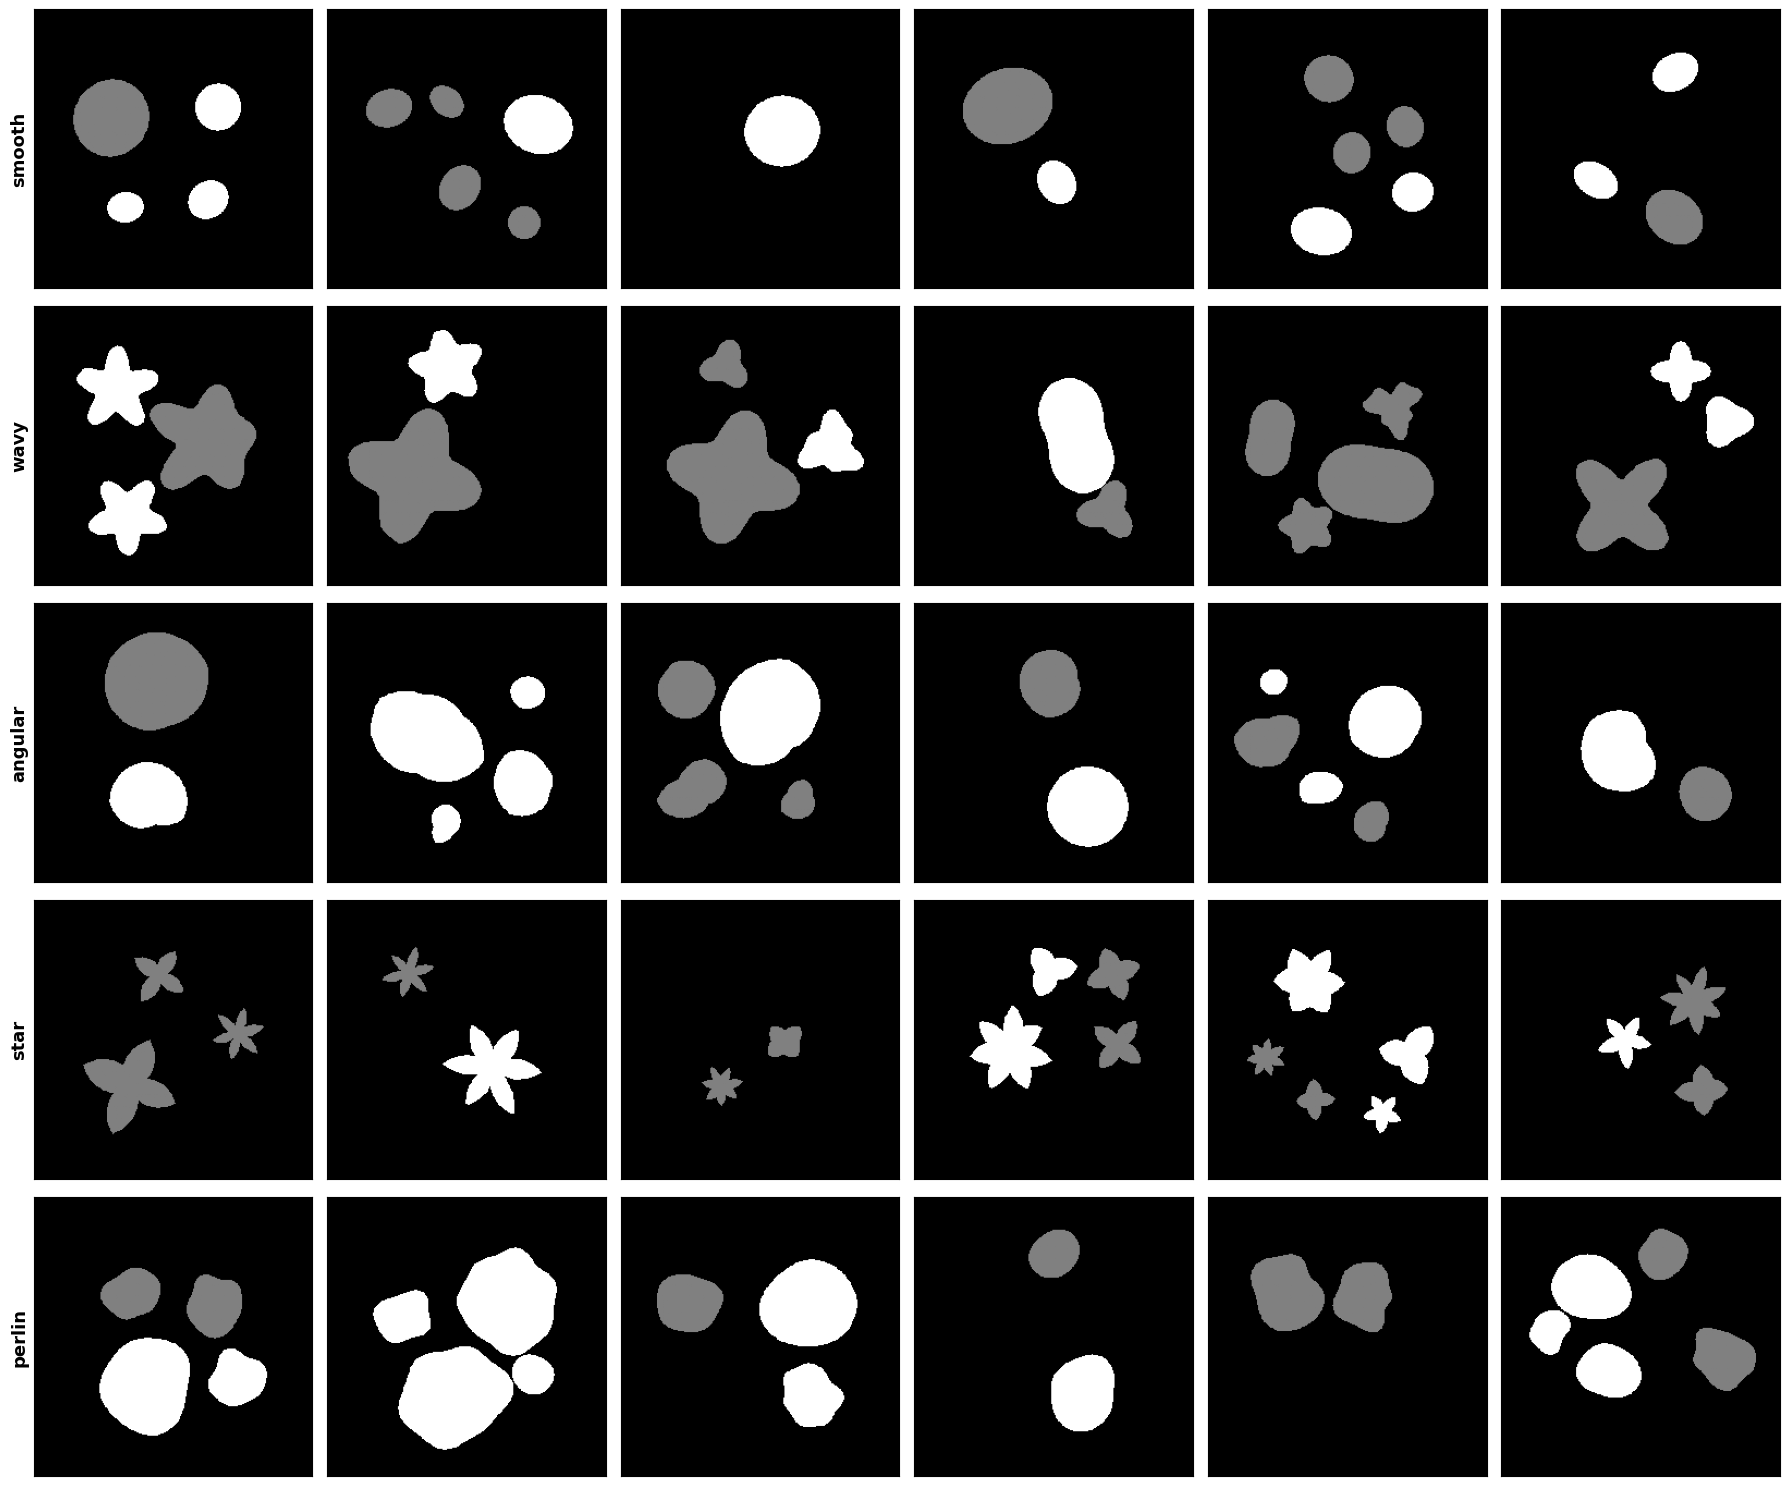

In [9]:
fig, axes = plt.subplots(5, 6, figsize=(18, 15))

for row, style in enumerate(CONTOUR_STYLES):
    # Force all inclusions to use this style
    weights = [1.0 if s == style else 0.0 for s in CONTOUR_STYLES]
    for col in range(6):
        mask = create_phantoms_advanced(
            style_weights=weights,
            rng=np.random.default_rng(row * 100 + col * 17 + 3))
        axes[row, col].imshow(mask.T, cmap='gray', origin='lower', vmin=0, vmax=2)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
    axes[row, 0].set_ylabel(style, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Batch Diversity Statistics

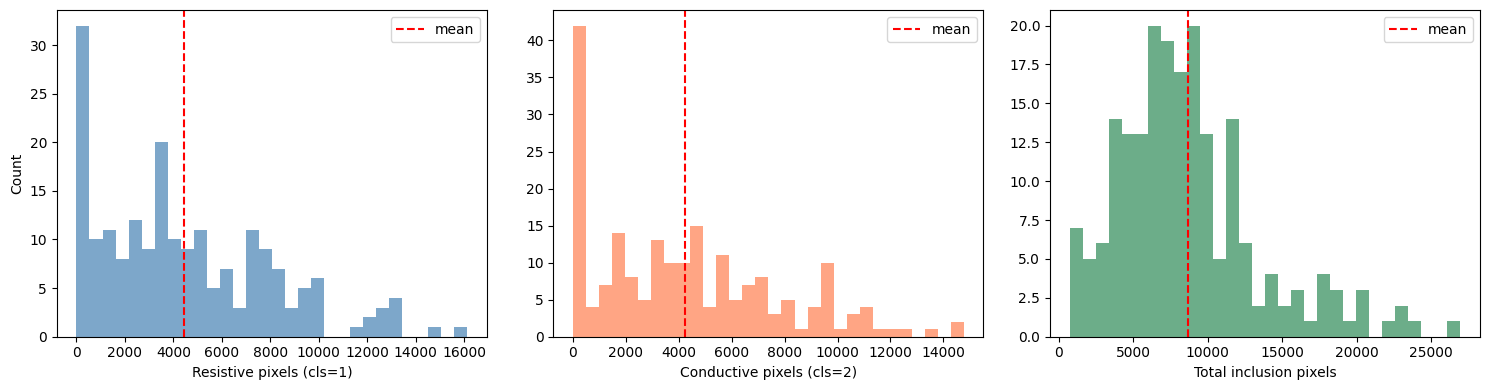

Resistive  (cls=1): mean=4456, std=3617
Conductive (cls=2): mean=4234, std=3546
Both classes: 127/200


In [10]:
n_batch = 200
rng_batch = np.random.default_rng(123)
stats = {'n_cls1': [], 'n_cls2': [], 'n_total': []}

for _ in range(n_batch):
    mask = create_phantoms_v2(rng=rng_batch)
    stats['n_cls1'].append((mask == 1).sum())
    stats['n_cls2'].append((mask == 2).sum())
    stats['n_total'].append((mask > 0).sum())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
keys = ['n_cls1', 'n_cls2', 'n_total']
labels = ['Resistive pixels (cls=1)', 'Conductive pixels (cls=2)',
          'Total inclusion pixels']
colors = ['steelblue', 'coral', 'seagreen']

for ax, key, label, color in zip(axes, keys, labels, colors):
    ax.hist(stats[key], bins=30, alpha=0.7, color=color)
    ax.axvline(np.mean(stats[key]), color='red', ls='--', label='mean')
    ax.set_xlabel(label)
    ax.legend()
axes[0].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'Resistive  (cls=1): mean={np.mean(stats["n_cls1"]):.0f}, '
      f'std={np.std(stats["n_cls1"]):.0f}')
print(f'Conductive (cls=2): mean={np.mean(stats["n_cls2"]):.0f}, '
      f'std={np.std(stats["n_cls2"]):.0f}')
print(f'Both classes: {sum(1 for a,b in zip(stats["n_cls1"],stats["n_cls2"]) if a>0 and b>0)}/{n_batch}')